In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        #print(os.path.join(dirname, filename))
        break

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# INITIAL IMPORTS AND SETTING UP THE ENVIRONMENT

In [2]:
# Importing necessary libraries
import glob
import math
import random
import cv2 as cv
import tensorflow as tf
from matplotlib import pyplot as plt

/opt/conda/lib/python3.10/site-packages/tensorflow_io/python/ops/__init__.py:98: UserWarning: unable to load libtensorflow_io_plugins.so: unable to open file: libtensorflow_io_plugins.so, from paths: ['/opt/conda/lib/python3.10/site-packages/tensorflow_io/python/ops/libtensorflow_io_plugins.so']
caused by: ['/opt/conda/lib/python3.10/site-packages/tensorflow_io/python/ops/libtensorflow_io_plugins.so: undefined symbol: _ZN3tsl6StatusC1EN10tensorflow5error4CodeESt17basic_string_viewIcSt11char_traitsIcEENS_14SourceLocationE']
  warnings.warn(f"unable to load libtensorflow_io_plugins.so: {e}")
/opt/conda/lib/python3.10/site-packages/tensorflow_io/python/ops/__init__.py:104: UserWarning: file system plugins are not loaded: unable to open file: libtensorflow_io.so, from paths: ['/opt/conda/lib/python3.10/site-packages/tensorflow_io/python/ops/libtensorflow_io.so']
caused by: ['/opt/conda/lib/python3.10/site-packages/tensorflow_io/python/ops/libtensorflow_io.so: undefined symbol: _ZTVN10tenso

In [3]:
train_folder = '/kaggle/input/sports-classification/train'
test_folder = '/kaggle/input/sports-classification/test'
validation_folder = '/kaggle/input/sports-classification/valid'

In [4]:
# Function to convert images from bgr to rgb channels

def get_rgb_image(image):
    rgb_image = cv.cvtColor(image, cv.COLOR_BGR2RGB)
    return rgb_image

# VISUALIZING THE DATA

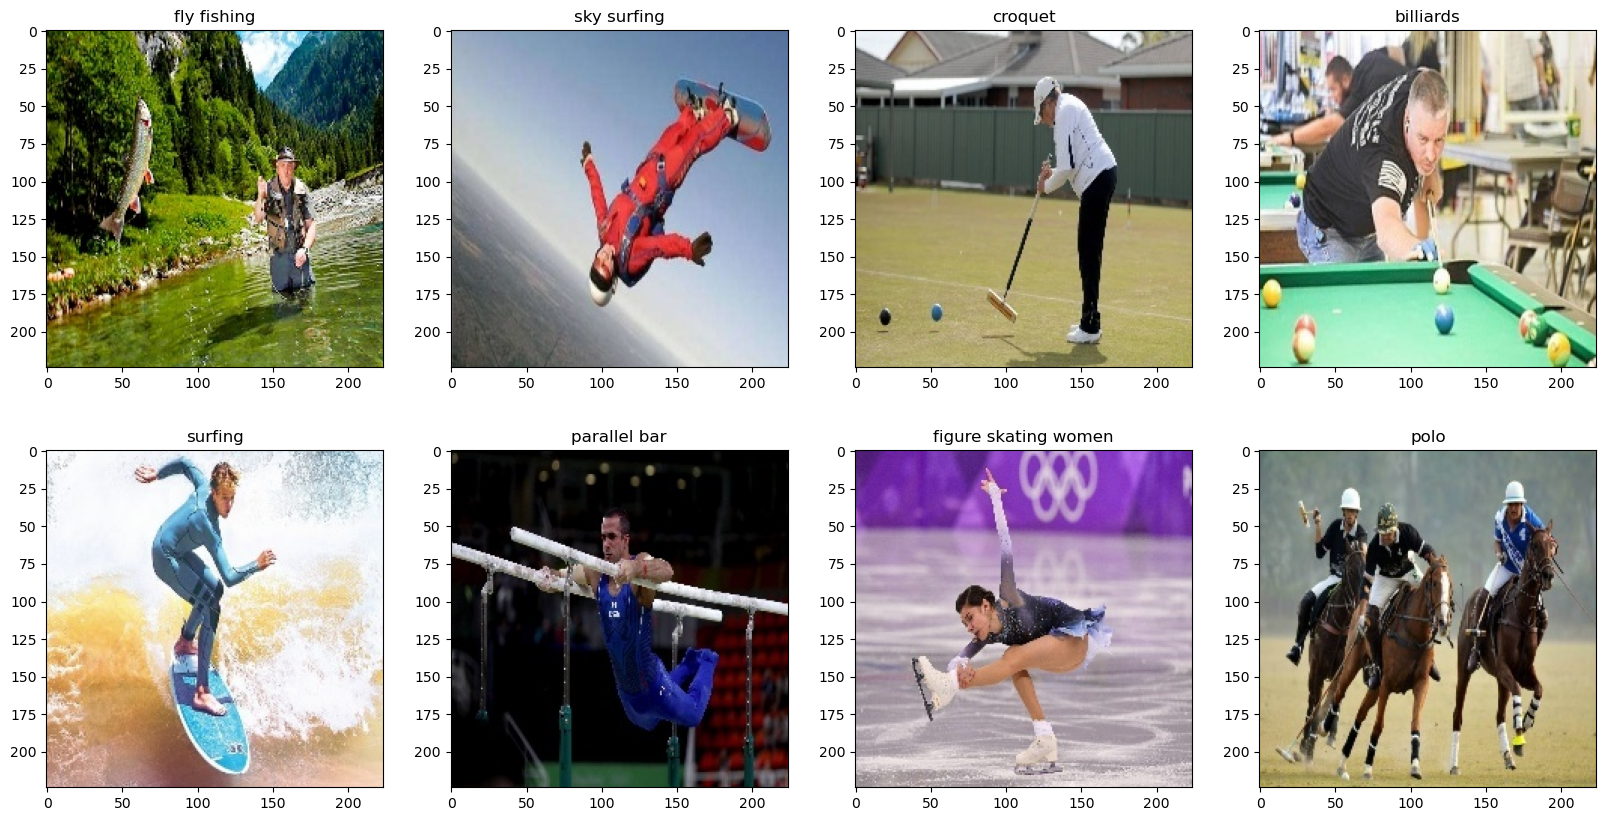

In [5]:
# Getting few random images from training data

def get_random_images(folder, n_images=8):
    c = 4
    r = math.ceil(n_images/c)
    
    plt.figure(figsize=(20,10))
    for i in range(n_images):
        plt.subplot(r,c,i+1)
        rand_image = random.choice(glob.glob(f'{folder}/*/*'))
        image = cv.imread(rand_image)
        plt.imshow(get_rgb_image(image))
        plt.title(rand_image.split('/')[-2]);

get_random_images(train_folder)

# CREATING DATA PIPELINE AND PREPROCESSING

In [6]:
# Using keras to load the data into pipeline 

train_data = tf.keras.utils.image_dataset_from_directory(train_folder)
#train_data = data.prefetch(tf.data.AUTOTUNE).cache()
validation_data = tf.keras.utils.image_dataset_from_directory(validation_folder) #.prefetch(tf.data.AUTOTUNE).cache()
class_names = train_data.class_names
batch = train_data.as_numpy_iterator().next()
batch[0].shape

Found 13492 files belonging to 100 classes.
Found 500 files belonging to 100 classes.


(32, 256, 256, 3)

In [7]:
# Let us get the class_names list which is arranged in accordance with the ascending order of label values. This means the index of class_names is the label assigned.

class_names[:5]

['air hockey', 'ampute football', 'archery', 'arm wrestling', 'axe throwing']

In [8]:
# Let us scale the data between 0 and 1. Since the rbg values are between 1 to 255 dividing by 255.

scaled_data = train_data.map(lambda x,y:(x/255,y)) 
scaled_val_data = validation_data.map(lambda x,y: (x/255, y))

# CREATING A DEEP NEURAL NETWORK MODEL

In [9]:
# Importing necessary functions and class for implementing CNN

from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout
from tensorflow.keras.metrics import Precision, Recall, BinaryAccuracy
from tensorflow.keras.models import load_model

In [10]:
model = Sequential()

model.add(Conv2D(filters=32, kernel_size = 3, strides=1, activation='relu', input_shape=(256,256,3)))
model.add(MaxPooling2D())

model.add(Conv2D(filters=64, kernel_size = 3, strides=1, activation='relu'))
model.add(MaxPooling2D())

model.add(Conv2D(filters=32, kernel_size = 3, strides=1, activation='relu'))
model.add(MaxPooling2D())

model.add(Flatten())

model.add(Dense(1000, activation='relu'))
model.add(Dense(100, activation='softmax'))

model.compile('adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 254, 254, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 127, 127, 32)     0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 125, 125, 64)      18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 62, 62, 64)       0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 60, 60, 32)        18464     
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 30, 30, 32)       0

In [11]:
import os
logdir='logs'
if not os.path.exists(logdir):
    os.mkdir(logdir)
tensor_logs = tf.keras.callbacks.TensorBoard(log_dir = logdir)
history = model.fit(scaled_data, epochs=10, validation_data=scaled_val_data, callbacks=[tensor_logs])

Epoch 1/10
422/422 [==============================] - 62s 124ms/step - loss: 3.8009 - accuracy: 0.1271 - val_loss: 2.9982 - val_accuracy: 0.2440
Epoch 2/10
422/422 [==============================] - 29s 69ms/step - loss: 2.2019 - accuracy: 0.4410 - val_loss: 2.8532 - val_accuracy: 0.3480
Epoch 3/10
422/422 [==============================] - 28s 66ms/step - loss: 0.7055 - accuracy: 0.8080 - val_loss: 4.2704 - val_accuracy: 0.3100
Epoch 4/10
422/422 [==============================] - 30s 71ms/step - loss: 0.2133 - accuracy: 0.9456 - val_loss: 4.8925 - val_accuracy: 0.2800
Epoch 5/10
422/422 [==============================] - 34s 81ms/step - loss: 0.1157 - accuracy: 0.9696 - val_loss: 5.2237 - val_accuracy: 0.3060
Epoch 6/10
422/422 [==============================] - 30s 69ms/step - loss: 0.0847 - accuracy: 0.9775 - val_loss: 5.5760 - val_accuracy: 0.3020
Epoch 7/10
422/422 [==============================] - 28s 66ms/step - loss: 0.0750 - accuracy: 0.9795 - val_loss: 6.9935 - val_accuracy

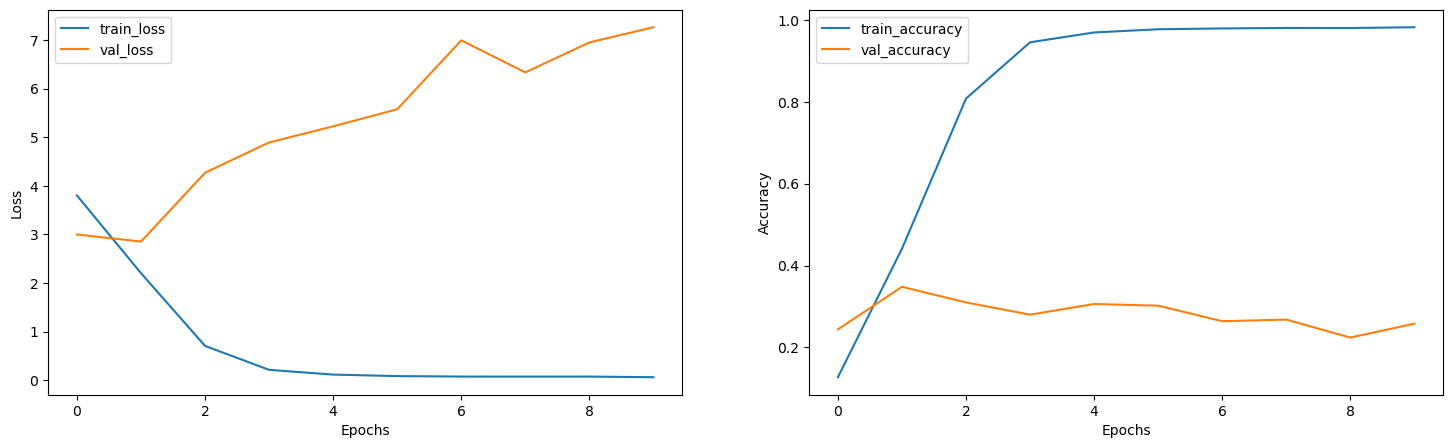

In [12]:
def plot_history_tf(model_history):

    plt.figure(figsize=(18,5))
    plt.subplot(1,2,1)
    plt.plot(model_history.history['loss'])
    plt.plot(model_history.history['val_loss'])
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend(['train_loss', 'val_loss'])

    plt.subplot(1,2,2)
    plt.plot(model_history.history['accuracy'])
    plt.plot(model_history.history['val_accuracy'])
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend(['train_accuracy', 'val_accuracy'])

    plt.show()
    
plot_history_tf(history)

#### We can observe from the plots that loss in validation set is increasing and accuracy is decreasing whereas in case of training data it is vice versa. 
#### This means that there is significant amount of overfitting done by the model. Hence, let us try to add some noise by augmenting the data.

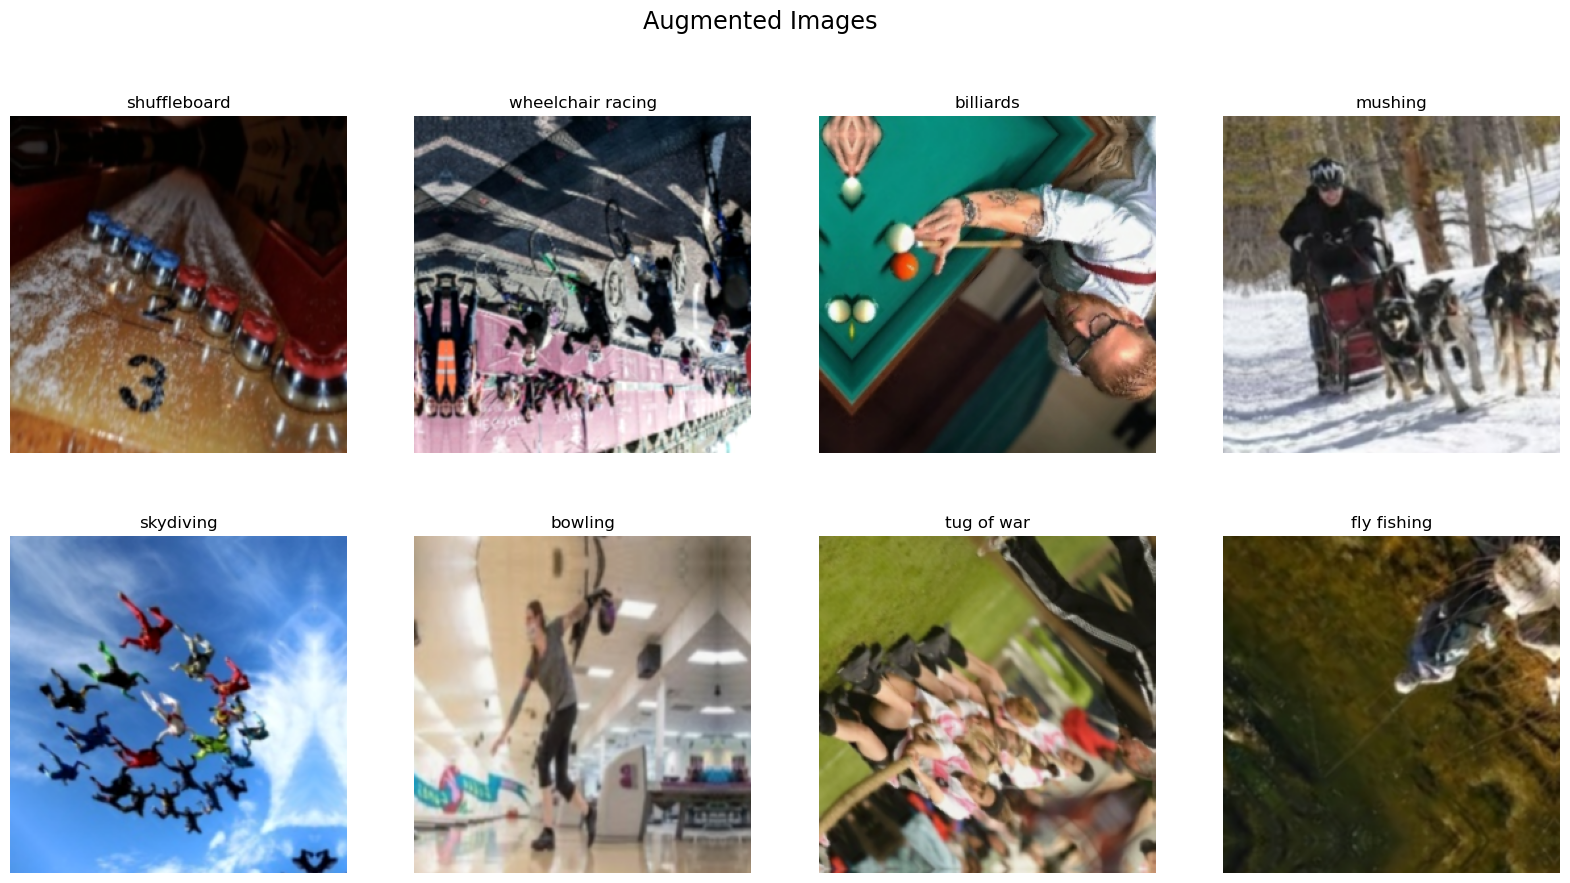

In [13]:
img_augmentation = Sequential(
    [
        layers.RandomRotation(factor=0.15),
        layers.RandomTranslation(height_factor=0.1, width_factor=0.1),
        layers.RandomFlip(),
        layers.RandomContrast(factor=0.1),
    ],
    name="img_augmentation",
)

plt.figure(figsize=(20,10))
plt.suptitle('Augmented Images', fontsize='xx-large')
for (i, img), label in zip(enumerate(batch[0]), batch[1]):
    result = img
    plt.subplot(2,4,i+1)
    plt.imshow(img_augmentation(img).numpy().astype(int))
    plt.title(class_names[label])
    plt.axis('off')
    if i == 7:
        break

In [14]:
model2 = Sequential(
    [
        layers.RandomRotation(factor=0.15),
        layers.RandomTranslation(height_factor=0.1, width_factor=0.1),
        layers.RandomFlip(),
        layers.RandomContrast(factor=0.1),
    ],
    name="img_augmentation",
)

model2.add(Conv2D(filters=32, kernel_size = 3, strides=1, activation='relu', input_shape=(256,256,3)))
model2.add(MaxPooling2D())

model2.add(Conv2D(filters=64, kernel_size = 3, strides=1, activation='relu'))
model2.add(MaxPooling2D())

model2.add(Conv2D(filters=32, kernel_size = 3, strides=1, activation='relu'))
model2.add(MaxPooling2D())

model2.add(Flatten())

model2.add(Dense(1000, activation='relu'))
model2.add(Dense(100, activation='softmax'))

model2.compile('adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

hist = model2.fit(scaled_data, epochs=10, validation_data=scaled_val_data, callbacks=[tensor_logs])

Epoch 1/10
422/422 [==============================] - 29s 62ms/step - loss: 4.4211 - accuracy: 0.0367 - val_loss: 4.1038 - val_accuracy: 0.0580
Epoch 2/10
422/422 [==============================] - 29s 66ms/step - loss: 3.9102 - accuracy: 0.0925 - val_loss: 3.5490 - val_accuracy: 0.1560
Epoch 3/10
422/422 [==============================] - 30s 70ms/step - loss: 3.4862 - accuracy: 0.1556 - val_loss: 3.1820 - val_accuracy: 0.2320
Epoch 4/10
422/422 [==============================] - 29s 67ms/step - loss: 3.1867 - accuracy: 0.2096 - val_loss: 2.9761 - val_accuracy: 0.2720
Epoch 5/10
422/422 [==============================] - 29s 69ms/step - loss: 2.9907 - accuracy: 0.2444 - val_loss: 2.9811 - val_accuracy: 0.2620
Epoch 6/10
422/422 [==============================] - 29s 66ms/step - loss: 2.8568 - accuracy: 0.2794 - val_loss: 2.7571 - val_accuracy: 0.3120
Epoch 7/10
422/422 [==============================] - 28s 64ms/step - loss: 2.7630 - accuracy: 0.2982 - val_loss: 2.6858 - val_accuracy:

#### It seems that problem related to overfitting is solved but the training is very slow. I tried training it by increasing the learning rate but it performs worse than the present model. 
#### Also, I tried to train the model for 30, 50 and 100 epochs but the validation accuracy reaches to upto maximum of 56% and then starts to overfit again resulting in reduction of validation accuracy. 
#### Hence let us try transfer learning and use pre trained models, such as EfficientNetB0 and MobileNet for our models.

# TRANSFER LEARNING

In [15]:
# Let us try first using Mobile Net from tensorflow applications

preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input

base_model = tf.keras.applications.MobileNetV2(input_shape=(256,256,3),
                                               include_top=False,
                                               weights='imagenet')

9406464/9406464 [==============================] - 0s 0us/step


In [16]:
image_batch, label_batch = next(iter(train_data))
feature_batch = base_model(image_batch)
base_model.trainable=False
base_model.summary()

Model: "mobilenetv2_1.00_224"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 256, 256, 3  0           []                               
                                )]                                                                
                                                                                                  
 Conv1 (Conv2D)                 (None, 128, 128, 32  864         ['input_1[0][0]']                
                                )                                                                 
                                                                                                  
 bn_Conv1 (BatchNormalization)  (None, 128, 128, 32  128         ['Conv1[0][0]']                  
                                )                                              

In [17]:
global_average_layer = tf.keras.layers.GlobalAveragePooling2D()
feature_batch_average = global_average_layer(feature_batch)
print(feature_batch_average.shape)

(32, 1280)


In [18]:
prediction_layer = tf.keras.layers.Dense(100)
prediction_batch = prediction_layer(feature_batch_average)
print(prediction_batch.shape)

(32, 100)


In [19]:
inputs = tf.keras.Input(shape=(256, 256, 3))
x = img_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)
x = global_average_layer(x)
x = tf.keras.layers.Dropout(0.2)(x)
outputs = prediction_layer(x)
model = tf.keras.Model(inputs, outputs)

In [20]:
base_learning_rate = 0.0001
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=base_learning_rate),
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 256, 256, 3)]     0         
                                                                 
 img_augmentation (Sequentia  (256, 256, 3)            0         
 l)                                                              
                                                                 
 tf.math.truediv (TFOpLambda  (None, 256, 256, 3)      0         
 )                                                               
                                                                 
 tf.math.subtract (TFOpLambd  (None, 256, 256, 3)      0         
 a)                                                              
                                                                 
 mobilenetv2_1.00_224 (Funct  (None, 8, 8, 1280)       2257984   
 ional)                                                      

In [21]:
initial_epochs = 25

history = model.fit(train_data,
                    epochs=initial_epochs,
                    validation_data=validation_data)

Epoch 1/25
422/422 [==============================] - 34s 70ms/step - loss: 4.3412 - accuracy: 0.0634 - val_loss: 3.6380 - val_accuracy: 0.2020
Epoch 2/25
422/422 [==============================] - 26s 60ms/step - loss: 3.3398 - accuracy: 0.2335 - val_loss: 2.8286 - val_accuracy: 0.4340
Epoch 3/25
422/422 [==============================] - 31s 72ms/step - loss: 2.7233 - accuracy: 0.3781 - val_loss: 2.2936 - val_accuracy: 0.5720
Epoch 4/25
422/422 [==============================] - 29s 68ms/step - loss: 2.3119 - accuracy: 0.4710 - val_loss: 1.9311 - val_accuracy: 0.6360
Epoch 5/25
422/422 [==============================] - 29s 66ms/step - loss: 2.0372 - accuracy: 0.5287 - val_loss: 1.6728 - val_accuracy: 0.6700
Epoch 6/25
422/422 [==============================] - 31s 73ms/step - loss: 1.8457 - accuracy: 0.5659 - val_loss: 1.4814 - val_accuracy: 0.6920
Epoch 7/25
422/422 [==============================] - 27s 64ms/step - loss: 1.6994 - accuracy: 0.5967 - val_loss: 1.3426 - val_accuracy:

In [22]:
# Fine tuning the pre-trained model 
base_model.trainable = True

print("Number of layers in the base model: ", len(base_model.layers))

fine_tune_at = 100

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

Number of layers in the base model:  154


In [23]:
model.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              optimizer = tf.keras.optimizers.RMSprop(learning_rate=base_learning_rate/10),
              metrics=['accuracy'])

In [24]:
fine_tune_epochs = 25
total_epochs =  initial_epochs + fine_tune_epochs

history_fine = model.fit(train_data,
                         epochs=total_epochs,
                         initial_epoch=history.epoch[-1],
                         validation_data=validation_data)

Epoch 25/50
422/422 [==============================] - 42s 74ms/step - loss: 0.8175 - accuracy: 0.7655 - val_loss: 0.4547 - val_accuracy: 0.8600
Epoch 26/50
422/422 [==============================] - 32s 74ms/step - loss: 0.7382 - accuracy: 0.7865 - val_loss: 0.4344 - val_accuracy: 0.8640
Epoch 27/50
422/422 [==============================] - 30s 70ms/step - loss: 0.6794 - accuracy: 0.8008 - val_loss: 0.4049 - val_accuracy: 0.8780
Epoch 28/50
422/422 [==============================] - 30s 69ms/step - loss: 0.6405 - accuracy: 0.8129 - val_loss: 0.4044 - val_accuracy: 0.8700
Epoch 29/50
422/422 [==============================] - 30s 70ms/step - loss: 0.6166 - accuracy: 0.8209 - val_loss: 0.3995 - val_accuracy: 0.8660
Epoch 30/50
422/422 [==============================] - 30s 69ms/step - loss: 0.5803 - accuracy: 0.8309 - val_loss: 0.3771 - val_accuracy: 0.8820
Epoch 31/50
422/422 [==============================] - 35s 83ms/step - loss: 0.5562 - accuracy: 0.8371 - val_loss: 0.3700 - val_ac

#### We and see that the accuracy of the model reaches to upto 94% after 50 epochs. Let us load the model which was provided to us along with the dataset.

# EFFICIENT NET B0

In [25]:
model_path = "/kaggle/input/sports-classification/EfficientNetB0-100-(224 X 224)- 98.40.h5"
efficient_model = load_model(model_path, compile=False)
test_data = tf.keras.utils.image_dataset_from_directory(test_folder, image_size=(224,224))
efficient_model.compile('RMSprop',loss='sparse_categorical_crossentropy', metrics=['accuracy'])
efficient_model.evaluate(test_data)

Found 500 files belonging to 100 classes.
16/16 [==============================] - 6s 84ms/step - loss: 0.3323 - accuracy: 0.9800


[0.332294762134552, 0.9800000190734863]

In [26]:
predictions = np.array([])
labels =  np.array([])
for x, y in test_data:
    predictions = np.concatenate([predictions , np.array([np.argmax(pred) for pred in efficient_model.predict(x, verbose=0)])])
    labels = np.concatenate([labels , np.array(y)])

cm = tf.math.confusion_matrix(labels=labels, predictions=predictions).numpy()

In [27]:
from sklearn.metrics import classification_report
print(classification_report(labels, predictions))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00         5
         1.0       1.00      1.00      1.00         5
         2.0       1.00      1.00      1.00         5
         3.0       1.00      1.00      1.00         5
         4.0       1.00      1.00      1.00         5
         5.0       1.00      1.00      1.00         5
         6.0       1.00      1.00      1.00         5
         7.0       1.00      1.00      1.00         5
         8.0       1.00      1.00      1.00         5
         9.0       1.00      1.00      1.00         5
        10.0       1.00      1.00      1.00         5
        11.0       1.00      1.00      1.00         5
        12.0       1.00      0.80      0.89         5
        13.0       1.00      1.00      1.00         5
        14.0       1.00      1.00      1.00         5
        15.0       1.00      1.00      1.00         5
        16.0       1.00      1.00      1.00         5
        17.0       1.00    

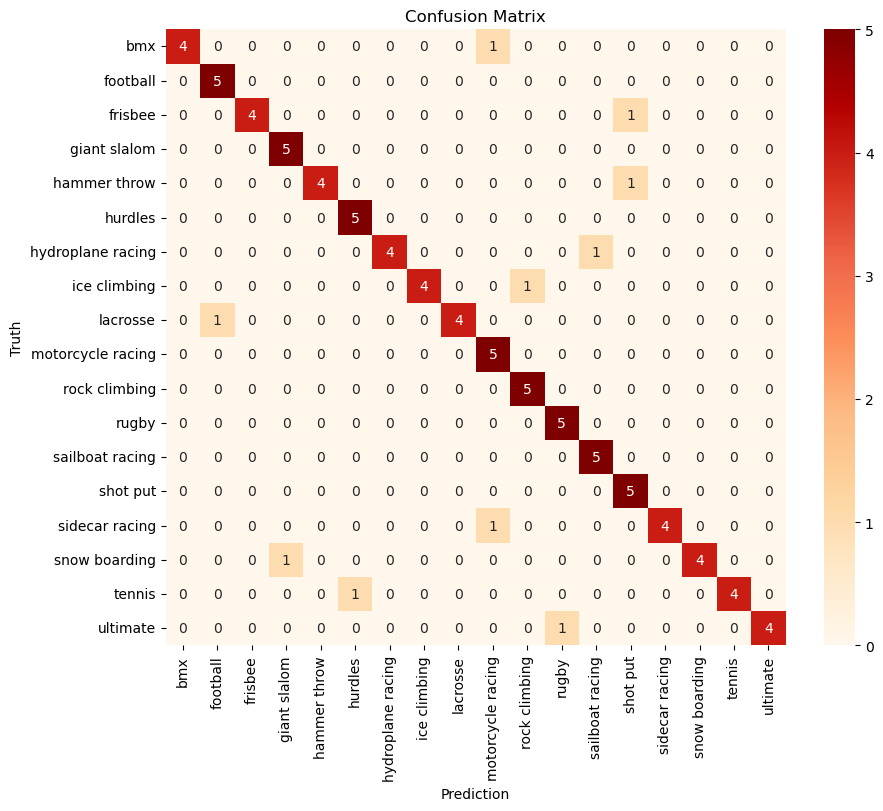

In [28]:
class_dict = {}
[class_dict.update({class_names.index(c):c}) for c in class_names]

cm_df = pd.DataFrame(data = cm)
new_df = cm_df.set_axis(cm_df.columns.map(class_dict), axis=1)

for i in range(len(new_df)):
    if cm_df[i][i] == 5 and cm_df[i].sum() == 5 and new_df.iloc[i].sum() == 5:
        cm_df.drop(i, axis=0, inplace=True)
        cm_df.drop(i, axis=1, inplace=True)


mappers = cm_df.columns.map(class_dict)
mapped_df = cm_df.set_axis(list(mappers), axis=1)
mapped_df = mapped_df.set_axis(list(mappers), axis=0)

import seaborn as sns
plt.figure(figsize=(10,8))
sns.heatmap(mapped_df, annot=True, cmap='OrRd')
plt.xlabel('Prediction')
plt.ylabel('Truth')
plt.title('Confusion Matrix')
plt.show()

# END OF CLASSIFICATION